# Análise da inferência do modelo particionado

Esse notebook é utilizado para fazer a análise dos dados obtidos nos experimentos referentes à performance do modelo particionado entre múltiplas GPUs. Aqui é utilizado o `summary.csv` gerado pelo notebook de pré-processamento dos dados.

In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


BASE_DIR = '../data_processed'
SUMMARY_PATH = os.path.join(BASE_DIR, 'summary.csv')

df = pd.read_csv(SUMMARY_PATH)
df['is_partitioned'] = df['parallelism'] != 'Single GPU'

### Helpers

Funções auxiliares para formatar nomes de experimentos e métricas nos gráficos

In [2]:
def pretty_metric_name(metric_name):
    return (
        metric_name
        .replace('_avg_ms', '')
        .replace('_avg', '')
        .replace('_', ' ')
        .title()
    )


def get_ylabel(metric_name):
    if '_ms' in metric_name:
        return 'Latency (ms)'
    if 'throughput' in metric_name:
        return 'Throughput (req/s)'
    return metric_name


def format_machine_nodes(machine_name):
    machine_name = machine_name.strip()

    match = re.match(r'([a-zA-Z]+)\[(\d+)-(\d+)\]', machine_name)
    if match:
        name = match.group(1).upper()
        start = int(match.group(2))
        end = int(match.group(3))
        nodes = ','.join(str(i) for i in range(start, end + 1))
        return f"{name} [{nodes}]"

    match = re.match(r'([a-zA-Z]+)(\d+)', machine_name)
    if match:
        return f"{match.group(1).upper()} [{match.group(2)}]"

    return machine_name.upper()


def format_experiment_name(row):
    parts = row['experiment_name'].split('_')
    workload = parts[3].capitalize() if len(parts) > 3 else ''

    machine_label = format_machine_nodes(row['machine_name'])

    parallelism = row['parallelism']
    strategy_label = 'No Comms' if parallelism == 'Single GPU' else parallelism

    return f"{machine_label} {strategy_label} {workload}"

### Visão geral por métrica

Para cada métrica de interesse plotamos uma barra por experimento, comparando todos os runs lado a lado.

In [3]:
metrics_to_plot = [
    'request_throughput_avg',
    'request_latency_avg_ms',
    'time_to_first_token_avg_ms',
    'input_sequence_length_avg',
    'output_sequence_length_avg',
    'output_token_throughput_avg',
    'inter_token_latency_avg_ms',
]

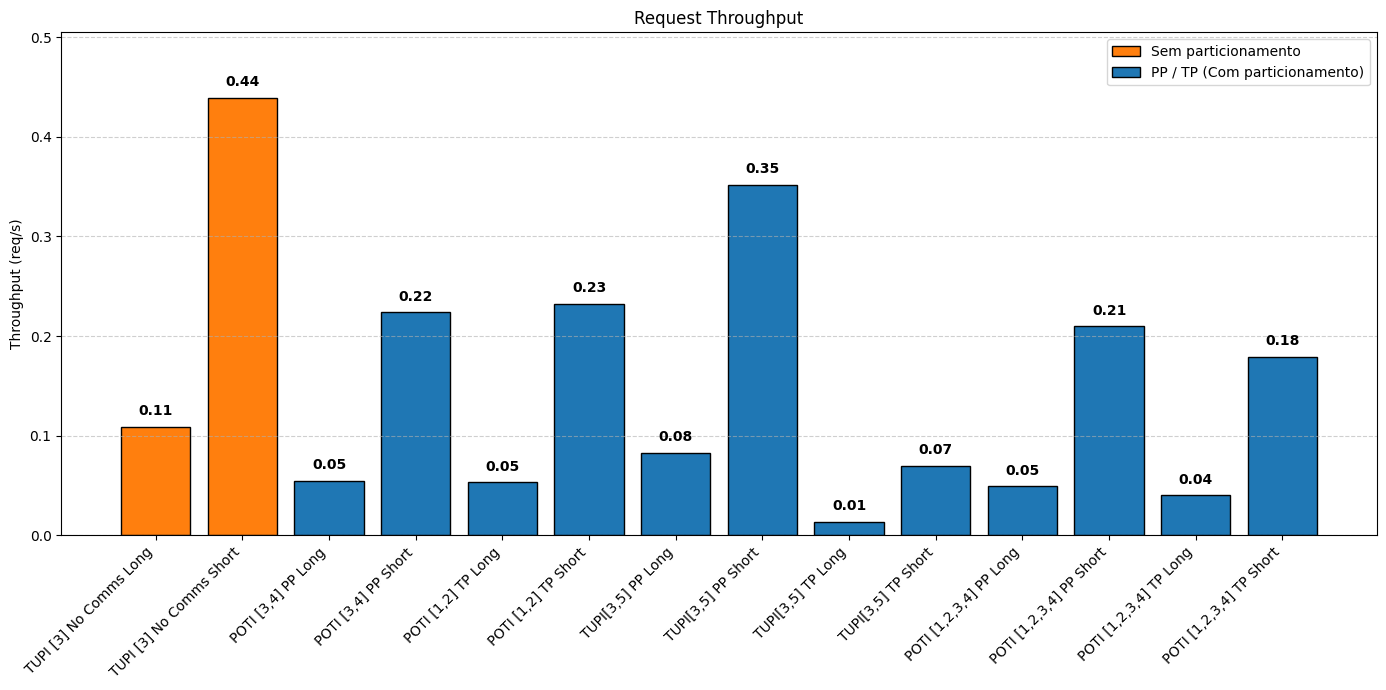

Saved: ../figures/02_analysis/request-throughput.png


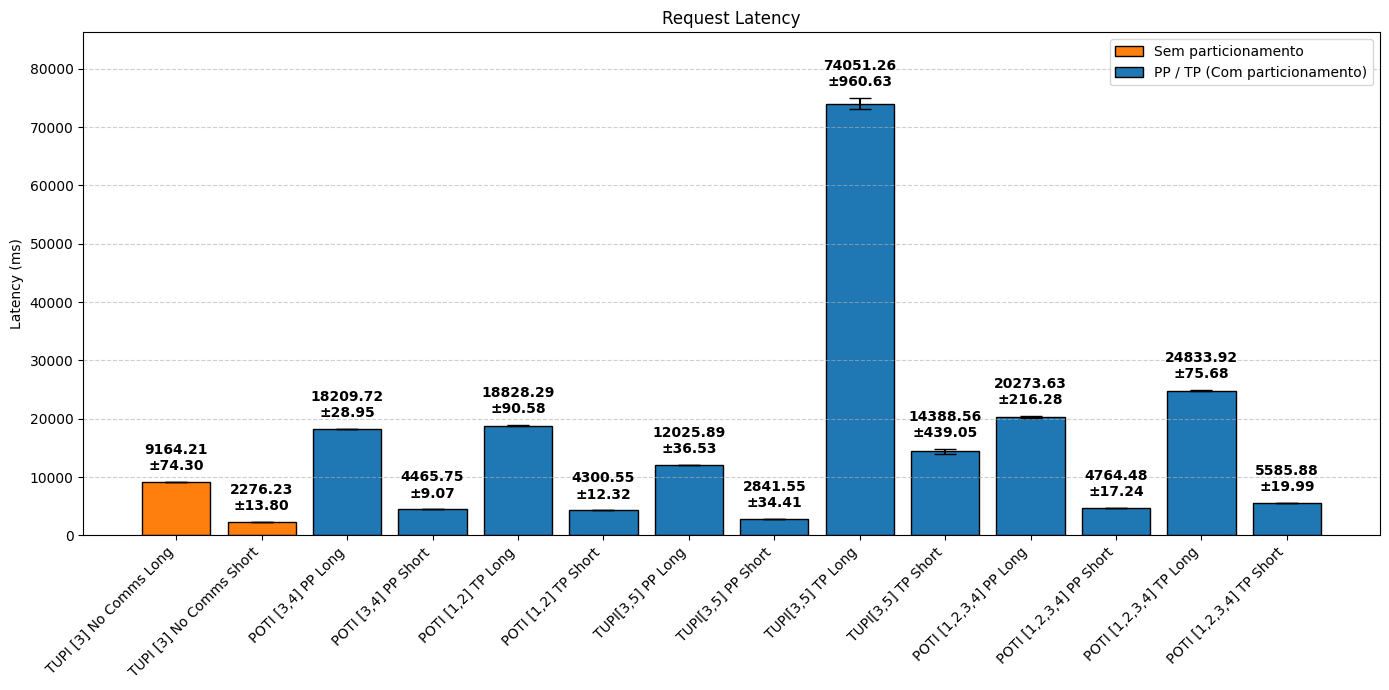

Saved: ../figures/02_analysis/request-latency.png


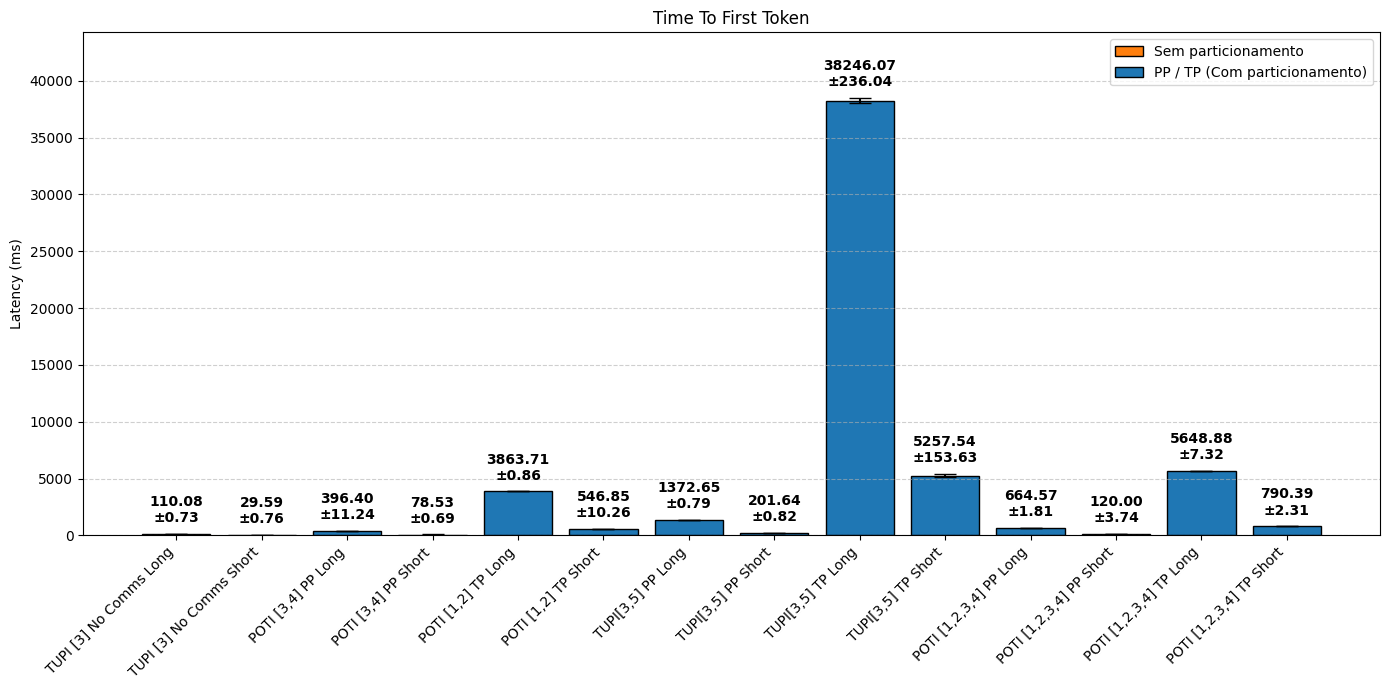

Saved: ../figures/02_analysis/time-to-first-token.png


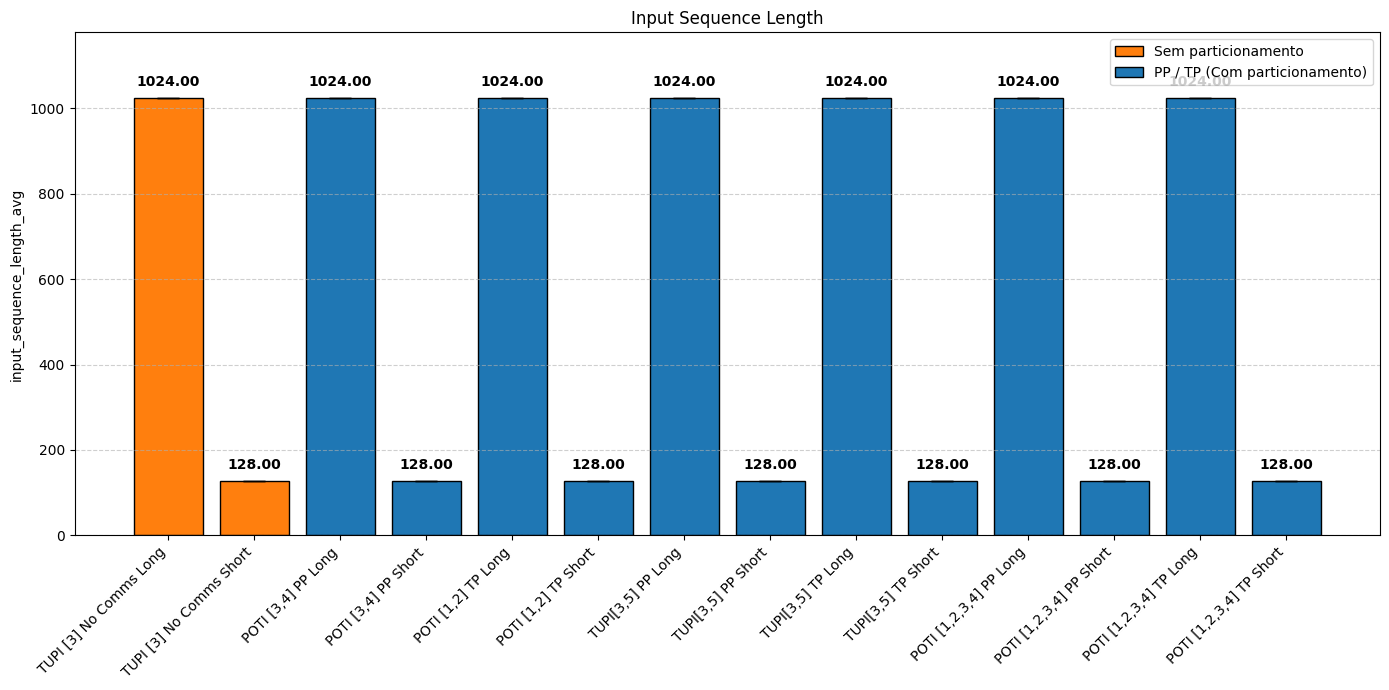

Saved: ../figures/02_analysis/input-sequence-length.png


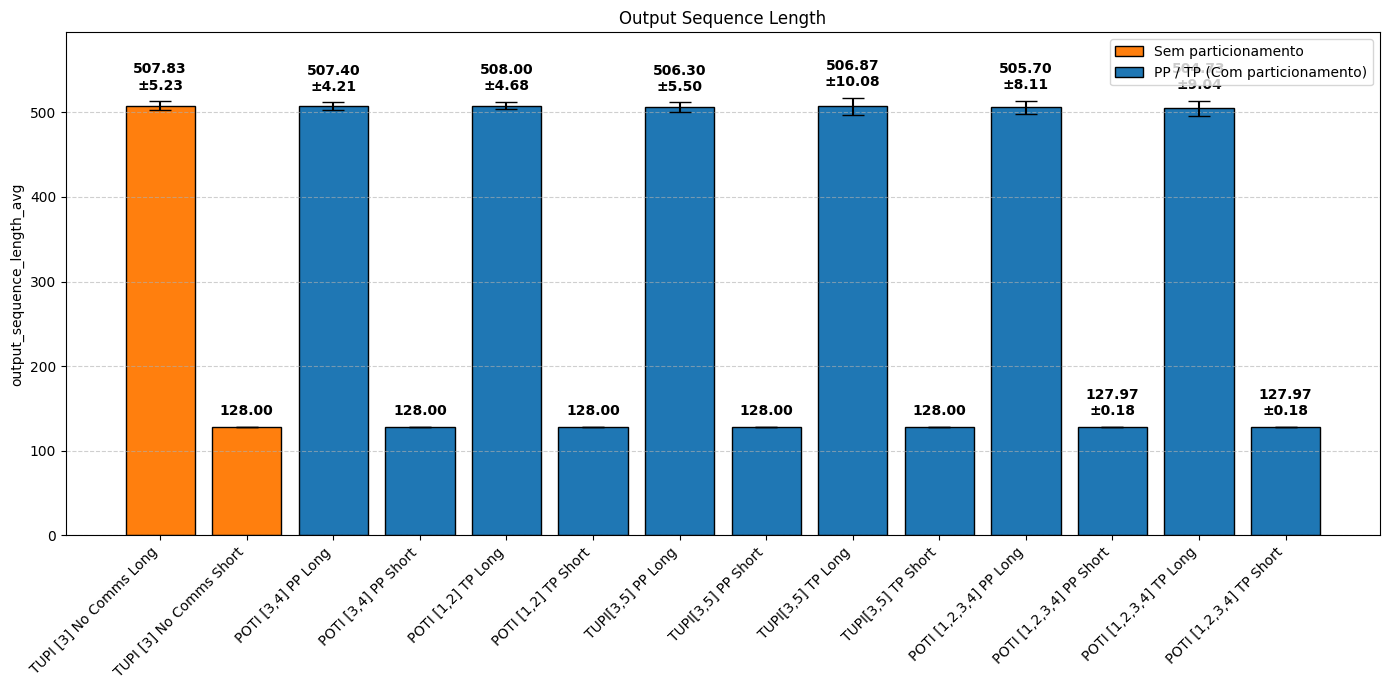

Saved: ../figures/02_analysis/output-sequence-length.png


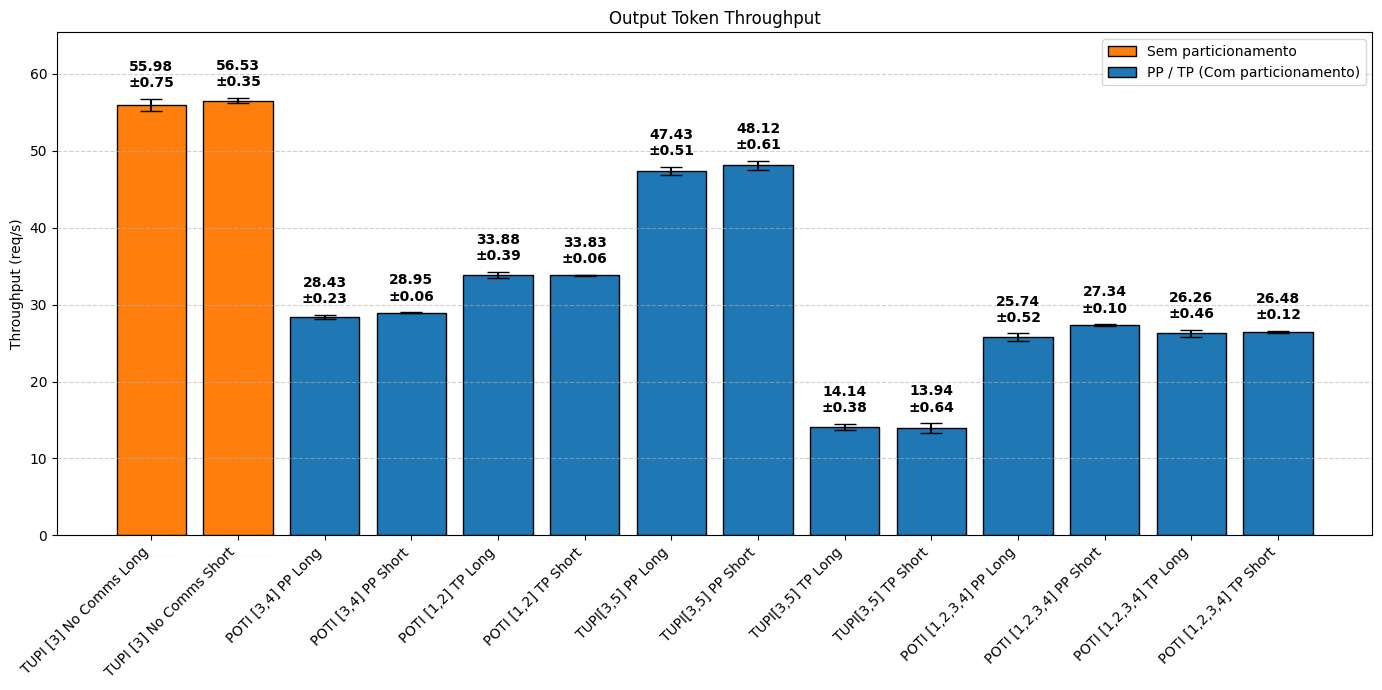

Saved: ../figures/02_analysis/output-token-throughput.png


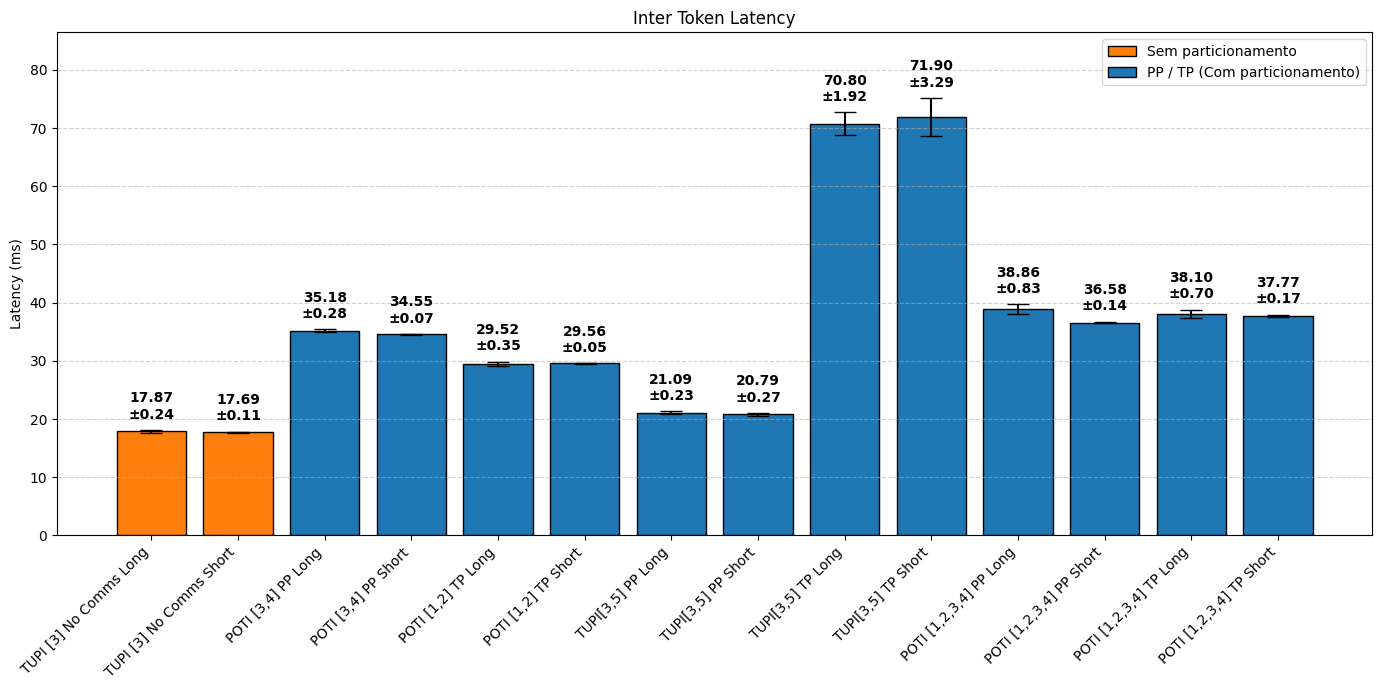

Saved: ../figures/02_analysis/inter-token-latency.png


In [4]:
output_dir = Path('../figures/inference_analysis')
output_dir.mkdir(parents=True, exist_ok=True)

for avg_col in metrics_to_plot:
    std_col = (
        avg_col.replace('_avg_ms', '_std_ms')
        if avg_col.endswith('_avg_ms')
        else avg_col.replace('_avg', '_std')
    )

    if avg_col not in df.columns:
        print(f"Skipping {avg_col}: column not found.")
        continue

    cols = ['experiment_name', 'display_name', 'parallelism',
            'machine_name', 'is_partitioned', avg_col]
    plot_df = df[cols].copy()

    if std_col in df.columns:
        plot_df[std_col] = df[std_col]

    plot_df = plot_df.dropna(subset=[avg_col])
    if plot_df.empty:
        continue

    plot_df = plot_df.sort_values('experiment_name').reset_index(drop=True)
    plot_df['pretty_name'] = plot_df.apply(format_experiment_name, axis=1)

    x = np.arange(len(plot_df))
    y = plot_df[avg_col].values

    has_std = std_col in plot_df.columns and plot_df[std_col].notna().any()
    yerr = plot_df[std_col].values if has_std else None

    colors = ['tab:blue' if comm else 'tab:orange'
              for comm in plot_df['is_partitioned']]

    plt.figure(figsize=(14, 7))
    plt.bar(x, y, yerr=yerr, capsize=8 if has_std else 0,
            color=colors, edgecolor='black', linewidth=1)

    offset = 0.02 * np.nanmax(y)
    max_height = 0
    for i, (xi, yi) in enumerate(zip(x, y)):
        label = f"{yi:.2f}"
        if has_std and not np.isnan(yerr[i]) and yerr[i] > 0:
            label += f"\n±{yerr[i]:.2f}"
            y_pos = yi + yerr[i] + offset
            max_height = max(max_height, yi + yerr[i])
        else:
            y_pos = yi + offset
            max_height = max(max_height, yi)

        plt.text(xi, y_pos, label, ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

    plt.ylim(0, max_height * 1.15)
    plt.xticks(x, plot_df['pretty_name'], rotation=45, ha='right')
    plt.ylabel(get_ylabel(avg_col))
    plt.title(pretty_metric_name(avg_col))
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    legend_elements = [
        Patch(facecolor='tab:orange', edgecolor='black', label='Sem particionamento'),
        Patch(facecolor='tab:blue', edgecolor='black', label='PP / TP (Com particionamento)'),
    ]
    plt.legend(handles=legend_elements)
    plt.tight_layout()

    filename = avg_col.replace('_avg_ms', '').replace('_avg', '').replace('_', '-')
    filepath = output_dir / f"{filename}.png"
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved: {filepath}")

### Diferença entre os dois tipos de particionamento TP e PP

A diferença entre as duas estratégias está no padrão de comunicação que cada uma exige:

- **TP (Tensor Parallel)** divide cada matriz dentro de uma camada e exige um *all-reduce* a cada camada, durante prefill e decode. Comunicação **fina e frequente**.
- **PP (Pipeline Parallel)** divide o modelo em estágios sequenciais e só transfere ativações nas fronteiras entre estágios. Comunicação **grossa e infrequente**.

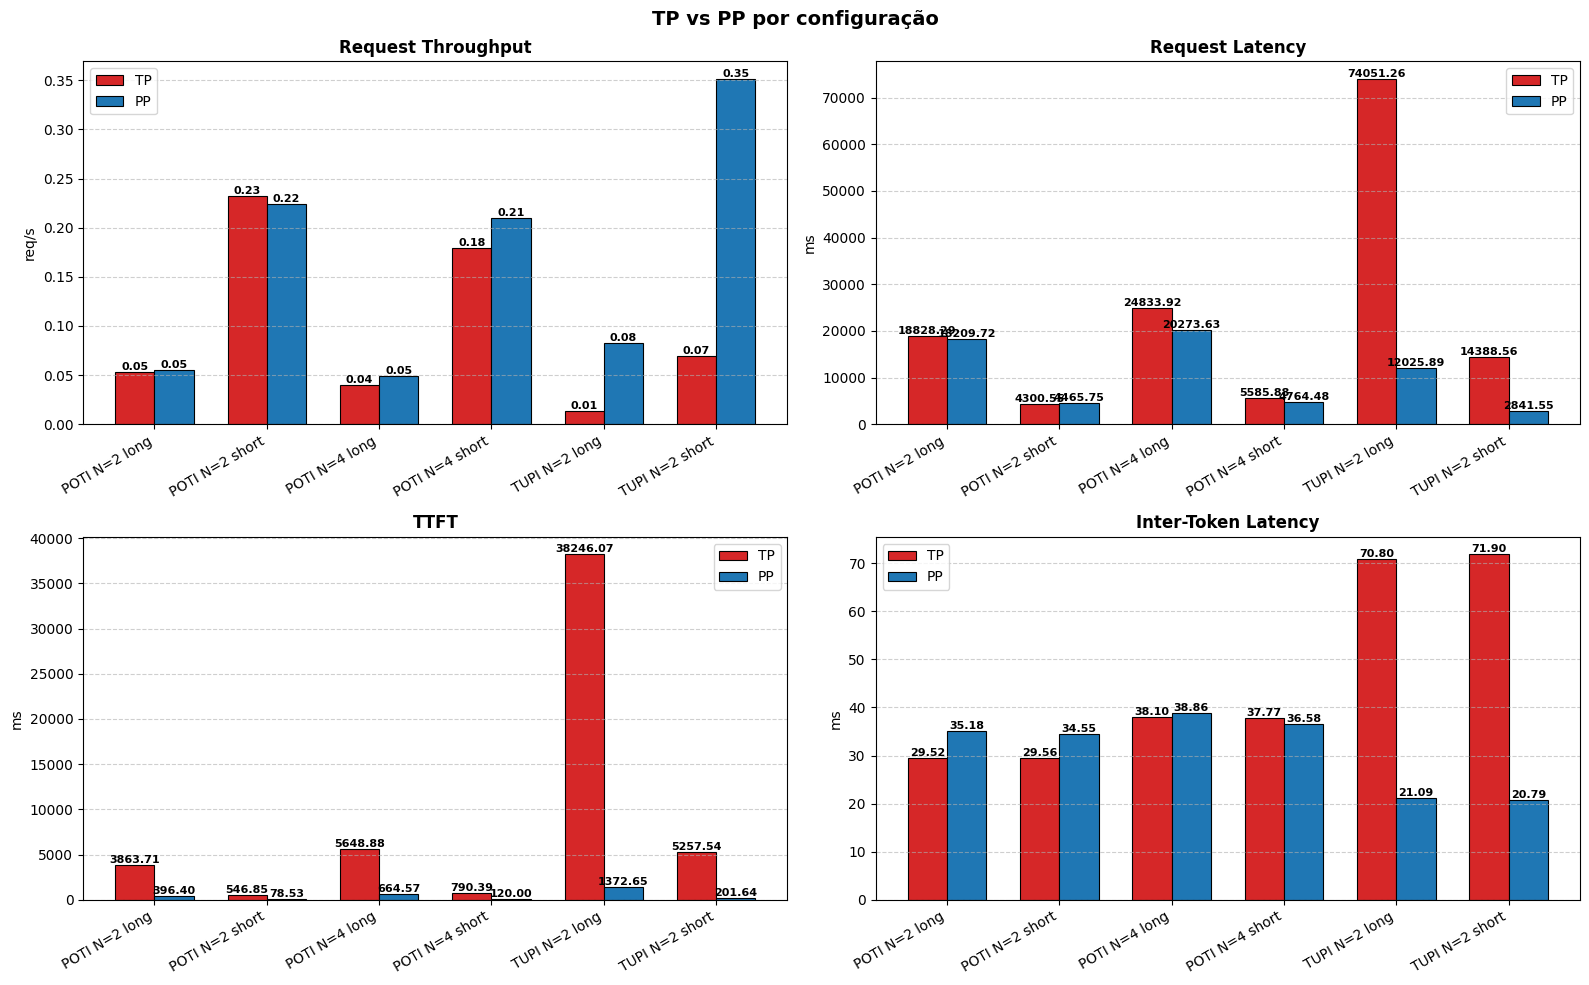

Saved: ../figures/02_analysis/tp-vs-pp.png


In [5]:
parallel_df = df[df['parallelism'].isin(['TP', 'PP'])].copy()


def parse_meta(name):
    parts = name.split('_')
    return pd.Series({
        'n_gpus': int(parts[0][1:]),
        'cluster': parts[1],
        'workload': parts[3],
    })


parallel_df = pd.concat(
    [parallel_df, parallel_df['experiment_name'].apply(parse_meta)], axis=1
)

main_metrics = {
    'request_throughput_avg': ('Request Throughput', 'req/s'),
    'request_latency_avg_ms': ('Request Latency', 'ms'),
    'time_to_first_token_avg_ms': ('TTFT', 'ms'),
    'inter_token_latency_avg_ms': ('Inter-Token Latency', 'ms'),
}

configs = (
    parallel_df[['cluster', 'n_gpus', 'workload']]
    .drop_duplicates()
    .sort_values(['cluster', 'n_gpus', 'workload'])
    .reset_index(drop=True)
)
config_labels = [
    f"{r['cluster'].upper()} N={r['n_gpus']} {r['workload']}"
    for _, r in configs.iterrows()
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

x = np.arange(len(configs))
bar_width = 0.35
strategy_color = {'TP': 'tab:red', 'PP': 'tab:blue'}

for idx, (metric, (title, ylabel)) in enumerate(main_metrics.items()):
    ax = axes[idx]
    for s_idx, strategy in enumerate(['TP', 'PP']):
        values = []
        for _, cfg in configs.iterrows():
            mask = (
                (parallel_df['cluster'] == cfg['cluster'])
                & (parallel_df['n_gpus'] == cfg['n_gpus'])
                & (parallel_df['workload'] == cfg['workload'])
                & (parallel_df['parallelism'] == strategy)
            )
            row = parallel_df[mask]
            values.append(row[metric].values[0] if len(row) else np.nan)

        offset = (s_idx - 0.5) * bar_width
        bars = ax.bar(x + offset, values, bar_width,
                      label=strategy, color=strategy_color[strategy],
                      edgecolor='black', linewidth=0.8)

        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{val:.2f}', ha='center', va='bottom',
                        fontsize=8, fontweight='bold')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(config_labels, rotation=30, ha='right')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('TP vs PP por configuração', fontsize=14, fontweight='bold')
plt.tight_layout()

tp_vs_pp_path = output_dir / 'tp-vs-pp.png'
plt.savefig(tp_vs_pp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {tp_vs_pp_path}")

### Escalabilidade na poti

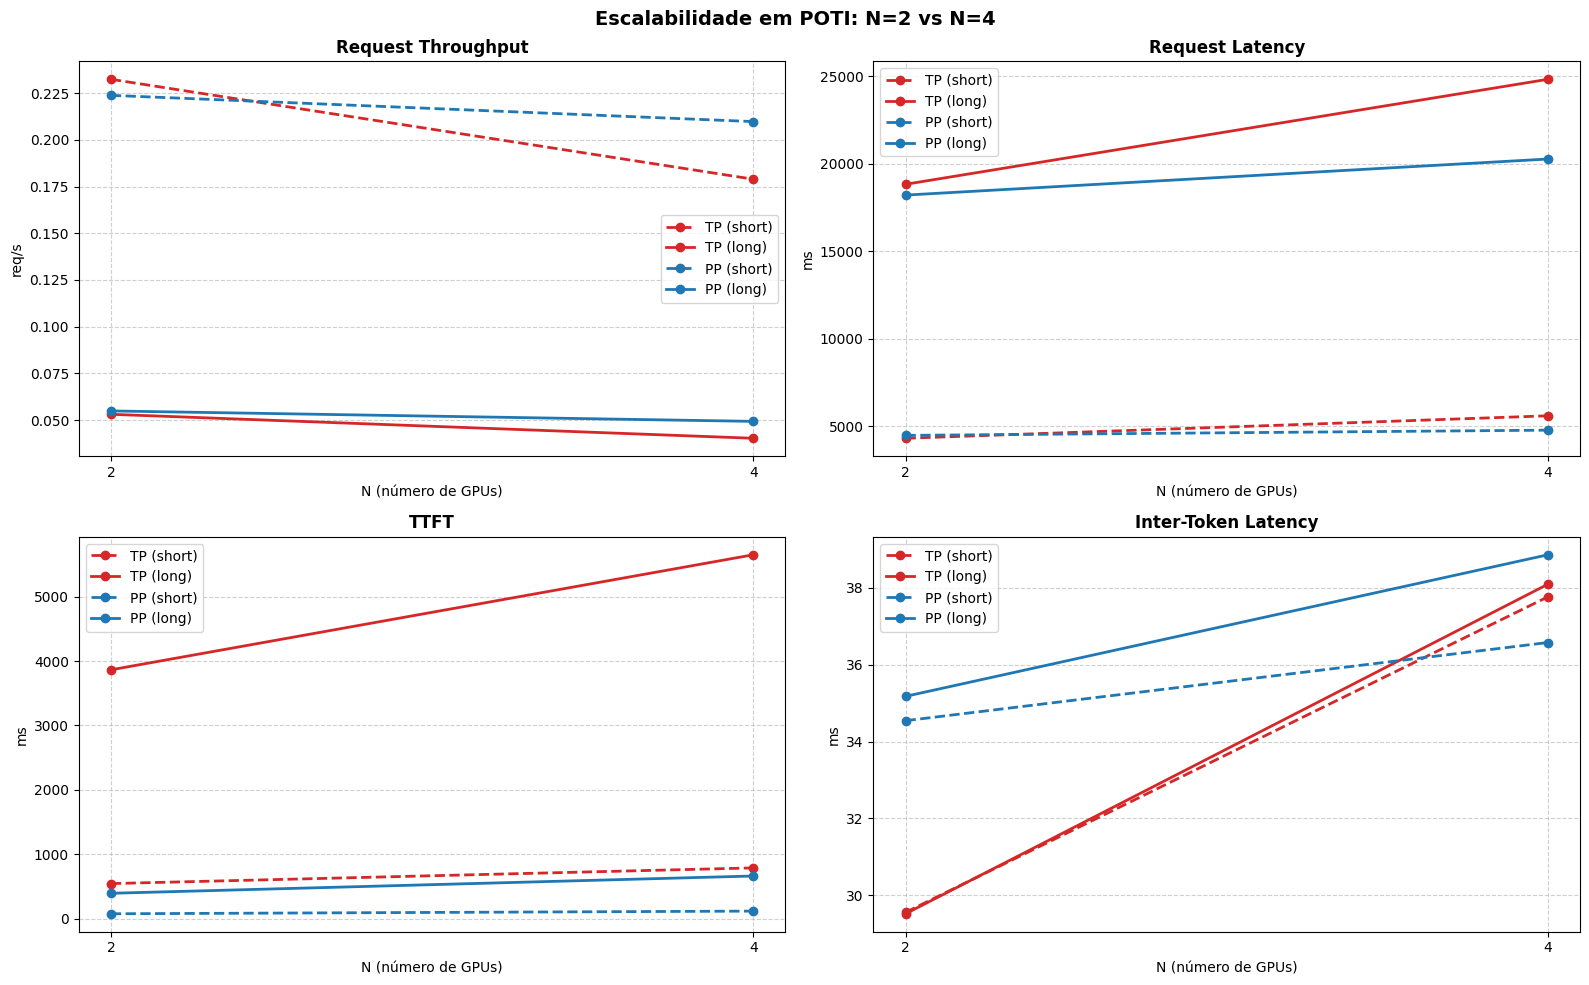

Saved: ../figures/02_analysis/scaling-poti.png


In [6]:
poti_df = parallel_df[parallel_df['cluster'] == 'poti'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (metric, (title, ylabel)) in enumerate(main_metrics.items()):
    ax = axes[idx]
    for strategy in ['TP', 'PP']:
        for workload in ['short', 'long']:
            sub = poti_df[
                (poti_df['parallelism'] == strategy)
                & (poti_df['workload'] == workload)
            ].sort_values('n_gpus')

            if sub.empty:
                continue

            ax.plot(
                sub['n_gpus'], sub[metric],
                marker='o', linewidth=2,
                color=strategy_color[strategy],
                linestyle='-' if workload == 'long' else '--',
                label=f"{strategy} ({workload})",
            )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('N (número de GPUs)')
    ax.set_ylabel(ylabel)
    ax.set_xticks([2, 4])
    ax.legend()
    ax.grid(linestyle='--', alpha=0.6)

fig.suptitle('Escalabilidade em POTI: N=2 vs N=4', fontsize=14, fontweight='bold')
plt.tight_layout()

scaling_path = output_dir / 'scaling-poti.png'
plt.savefig(scaling_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {scaling_path}")

### Efeito do workload

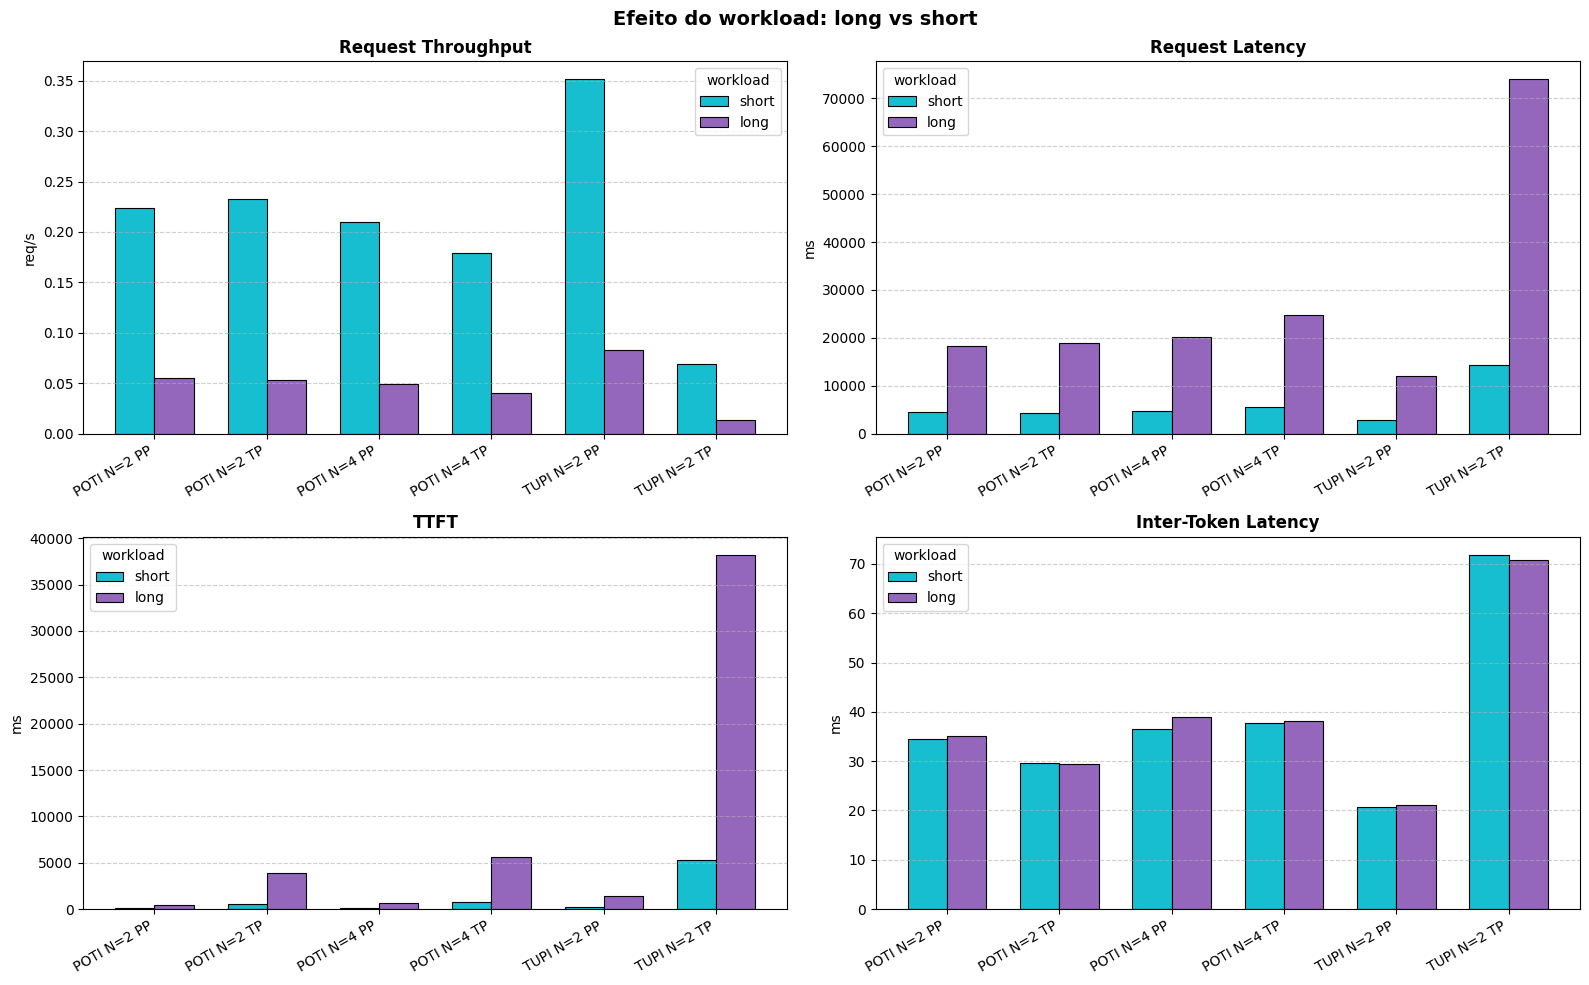

Saved: ../figures/02_analysis/workload-effect.png


In [7]:
config_keys = (
    parallel_df[['cluster', 'n_gpus', 'parallelism']]
    .drop_duplicates()
    .sort_values(['cluster', 'n_gpus', 'parallelism'])
    .reset_index(drop=True)
)
wl_labels = [
    f"{r['cluster'].upper()} N={r['n_gpus']} {r['parallelism']}"
    for _, r in config_keys.iterrows()
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

x = np.arange(len(config_keys))
bar_width = 0.35
workload_color = {'short': 'tab:cyan', 'long': 'tab:purple'}

for idx, (metric, (title, ylabel)) in enumerate(main_metrics.items()):
    ax = axes[idx]
    for w_idx, workload in enumerate(['short', 'long']):
        values = []
        for _, cfg in config_keys.iterrows():
            mask = (
                (parallel_df['cluster'] == cfg['cluster'])
                & (parallel_df['n_gpus'] == cfg['n_gpus'])
                & (parallel_df['parallelism'] == cfg['parallelism'])
                & (parallel_df['workload'] == workload)
            )
            row = parallel_df[mask]
            values.append(row[metric].values[0] if len(row) else np.nan)

        offset = (w_idx - 0.5) * bar_width
        ax.bar(x + offset, values, bar_width,
               label=workload, color=workload_color[workload],
               edgecolor='black', linewidth=0.8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(wl_labels, rotation=30, ha='right')
    ax.legend(title='workload')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Efeito do workload: long vs short', fontsize=14, fontweight='bold')
plt.tight_layout()

workload_path = output_dir / 'workload-effect.png'
plt.savefig(workload_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {workload_path}")